# Sprint 3 — Data Pipeline Report

## Objective

This notebook verifies and reports on the data pipeline built in `src/data/`
for Sprint 3 (`dataset.py`, `transforms.py`, `dataloader.py`, `label_map.py`,
`loaders.py`). No pipeline code is written here — this notebook only
imports from `src`, runs it against both datasets (mushroom, flower), and
reports the results. Any bug found here gets fixed in `src/`, not here.

Research question: can a single, reusable, configuration-driven data
pipeline serve both datasets without dataset-specific code paths?

What we check:

- Dataset sanity: `dataset[0]` shape and value range
- Batch shape sanity: `next(iter(loader))`
- Batch visualization (labels + augmented images)
- Augmentation on/off comparison (does augmentation actually do something?)
- A mini benchmark: image size, batch size, augmentation on/off vs load time

## 2. Imports

In [1]:
import time

import matplotlib.pyplot as plt
import pandas as pd
import torch

from src.data.config import load_config
from src.data.dataloader import build_dataloader, build_pipeline
from src.data.label_map import invert_label_map
from src.data.transforms import build_train_transform, build_val_transform, unnormalize

## 3. Load Configs

`configs/mushroom.yaml` and `configs/flower.yaml` hold everything that's
dataset-specific: root path, image size, batch size, augmentation preset,
crop scale, label map location. The pipeline code itself never mentions
"mushroom" or "flower" anywhere.

In [2]:
mushroom_config = load_config("configs/mushroom.yaml")
flower_config = load_config("configs/flower.yaml")

mushroom_config, flower_config

({'dataset_type': 'mushroom',
  'dataset_root': 'datasets/extracted/mushroom',
  'label_map_path': 'configs/label_maps/mushroom_label_map.json',
  'image_size': 224,
  'batch_size': 32,
  'num_workers': 4,
  'pin_memory': False,
  'augmentation_preset': 'light',
  'random_resized_crop_scale': [0.9, 1.0]},
 {'dataset_type': 'flower',
  'dataset_root': 'datasets/extracted/flower_data',
  'label_map_path': 'configs/label_maps/flower_label_map.json',
  'image_size': 224,
  'batch_size': 32,
  'num_workers': 4,
  'pin_memory': False,
  'augmentation_preset': 'heavy',
  'random_resized_crop_scale': [0.7, 1.0]})

## 4. Build Pipelines

`build_pipeline()` is the only place that wires loaders, label map,
transforms, datasets and dataloaders together for a given config.

In [3]:
mushroom_pipeline = build_pipeline(mushroom_config)
flower_pipeline = build_pipeline(flower_config)

print("Mushroom — train/val/test sizes:",
      len(mushroom_pipeline["train_dataset"]),
      len(mushroom_pipeline["val_dataset"]),
      len(mushroom_pipeline["test_dataset"]))
print("Mushroom — number of classes:", len(mushroom_pipeline["label_map"]))

print("Flower   — train/val/test sizes:",
      len(flower_pipeline["train_dataset"]),
      len(flower_pipeline["val_dataset"]),
      len(flower_pipeline["test_dataset"]))
print("Flower   — number of classes:", len(flower_pipeline["label_map"]))

Mushroom — train/val/test sizes: 689520 15616 15614
Mushroom — number of classes: 169
Flower   — train/val/test sizes: 6552 818 819
Flower   — number of classes: 102


## 5. Dataset Sanity Check

`dataset[0]` should return a `(3, image_size, image_size)` tensor. We also
print the value range: after `Normalize` with ImageNet mean/std, this should
sit roughly in `[-2.1, 2.6]` — if it doesn't (e.g. it's still `[0, 1]`),
`Normalize` silently isn't being applied, which is exactly the kind of bug
that trains a model quietly worse without throwing an error.

In [4]:
for name, pipeline in [("Mushroom", mushroom_pipeline), ("Flower", flower_pipeline)]:
    image, label = pipeline["train_dataset"][0]
    print(f"{name}: shape={tuple(image.shape)}, dtype={image.dtype}, "
          f"range=({image.min().item():.3f}, {image.max().item():.3f}), label_index={label}")

    # The flower test split has no labels — confirm it degrades to -1 instead of crashing.
    test_image, test_label = pipeline["test_dataset"][0]
    print(f"{name} test split first label (expected -1 for flower, a real index for mushroom): {test_label}")

Mushroom: shape=(3, 224, 224), dtype=torch.float32, range=(-2.049, 2.640), label_index=98
Mushroom test split first label (expected -1 for flower, a real index for mushroom): 168
Flower: shape=(3, 224, 224), dtype=torch.float32, range=(-2.118, 2.082), label_index=71
Flower test split first label (expected -1 for flower, a real index for mushroom): -1


## 6. Batch Shape Check

`images.shape` should be `(batch_size, 3, image_size, image_size)`,
`labels.shape` should be `(batch_size,)`.

In [5]:
for name, pipeline in [("Mushroom", mushroom_pipeline), ("Flower", flower_pipeline)]:
    images, labels = next(iter(pipeline["train_loader"]))
    print(f"{name}: images.shape={tuple(images.shape)}, labels.shape={tuple(labels.shape)}")

Mushroom: images.shape=(32, 3, 224, 224), labels.shape=(32,)


Flower: images.shape=(32, 3, 224, 224), labels.shape=(32,)


## 7. Batch Visualization

8 images from a single training batch, unnormalized back to `[0, 1]` for
display, with their decoded (human-readable) label.

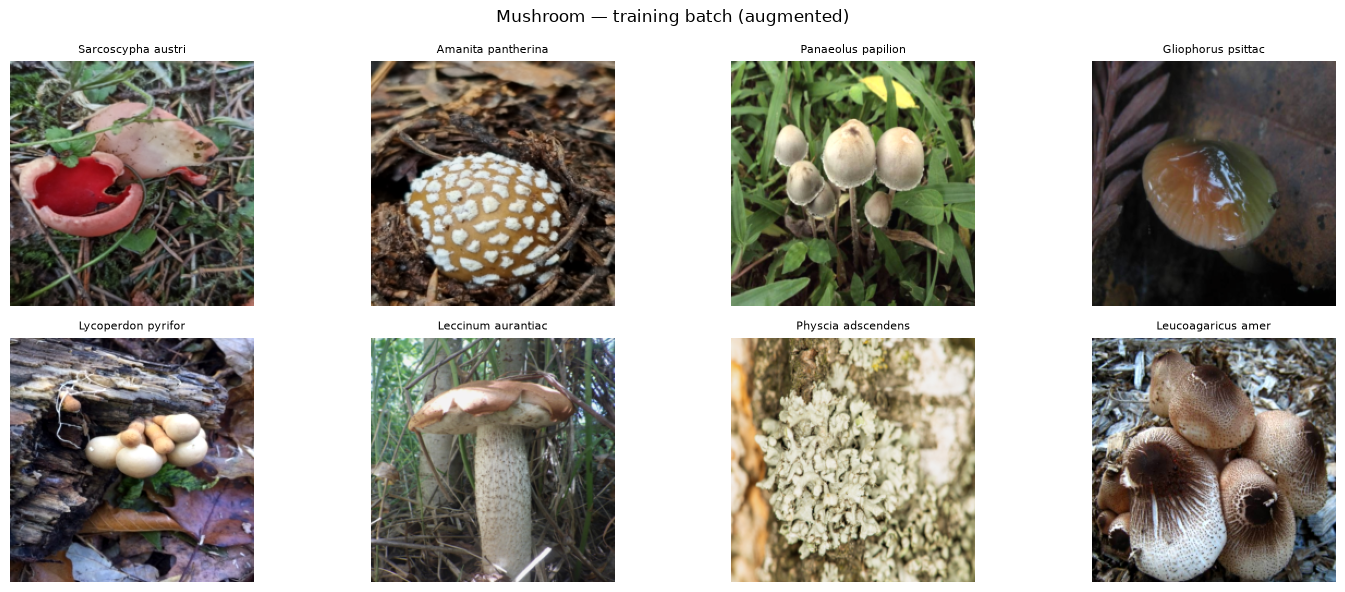

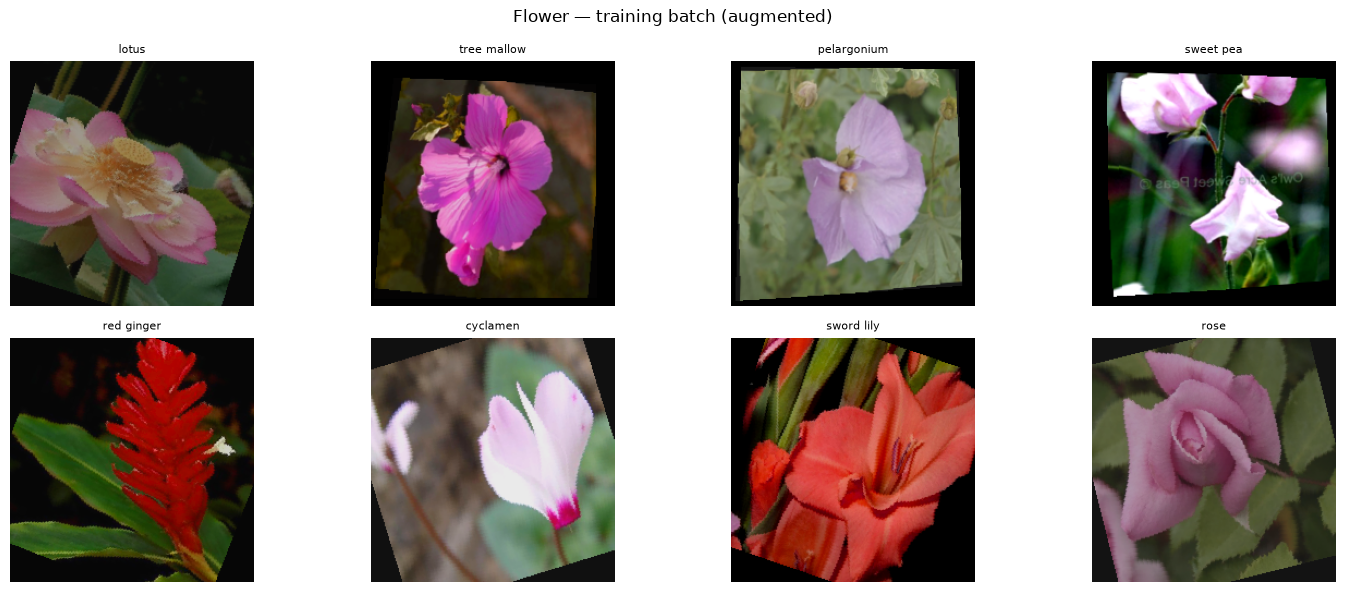

In [6]:
def show_batch(pipeline, title, n=8):
    images, labels = next(iter(pipeline["train_loader"]))
    idx_to_label = invert_label_map(pipeline["label_map"])

    fig, axes = plt.subplots(2, n // 2, figsize=(15, 6))
    for ax, image, label in zip(axes.flatten(), images[:n], labels[:n]):
        img = unnormalize(image).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(idx_to_label[label.item()][:18], fontsize=8)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_batch(mushroom_pipeline, "Mushroom — training batch (augmented)")
show_batch(flower_pipeline, "Flower — training batch (augmented)")

## 8. Augmentation On/Off Comparison

Sanity check that augmentation is actually doing something (and that the
"light" vs "heavy" presets look meaningfully different) — the same source
image, once through the un-augmented val transform and five times through
the dataset's own train transform.

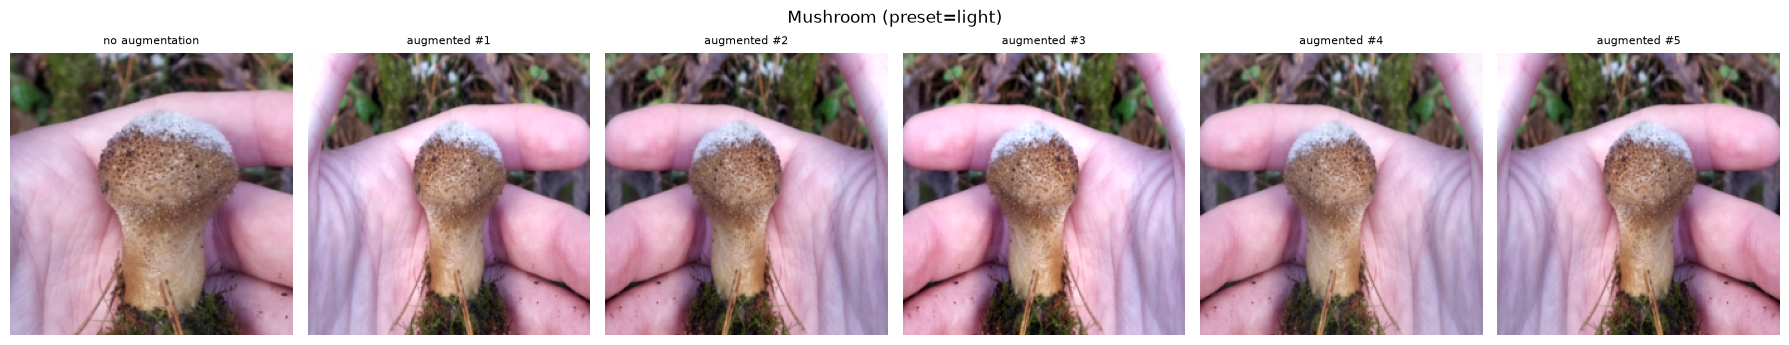

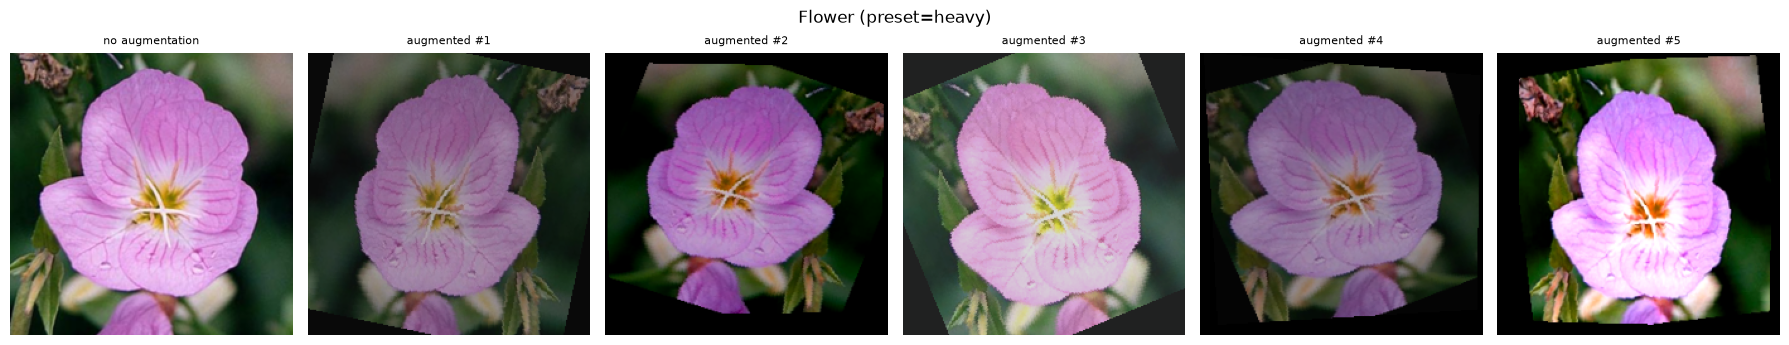

In [7]:
def show_augmentation_comparison(config, pipeline, title):
    row = pipeline["frames"]["train"].iloc[0]
    from PIL import Image
    image = Image.open(row["local_path"]).convert("RGB")

    val_transform = build_val_transform(config["image_size"])
    train_transform = build_train_transform(
        image_size=config["image_size"],
        augmentation_preset=config["augmentation_preset"],
        random_resized_crop_scale=tuple(config["random_resized_crop_scale"]),
    )

    variants = [("no augmentation", val_transform(image))]
    for i in range(5):
        variants.append((f"augmented #{i+1}", train_transform(image)))

    fig, axes = plt.subplots(1, len(variants), figsize=(18, 3.5))
    for ax, (label, tensor) in zip(axes, variants):
        img = unnormalize(tensor).clamp(0, 1).permute(1, 2, 0).numpy()
        ax.imshow(img)
        ax.set_title(label, fontsize=8)
        ax.axis("off")
    preset = config["augmentation_preset"]
    fig.suptitle(f"{title} (preset={preset})")
    plt.tight_layout()
    plt.show()


show_augmentation_comparison(mushroom_config, mushroom_pipeline, "Mushroom")
show_augmentation_comparison(flower_config, flower_pipeline, "Flower")

## 9. Mini Pipeline Benchmark

A small, deliberately cheap benchmark: for each dataset, time how long it
takes to pull 5 batches from the train loader under different `image_size`,
`batch_size` and augmentation settings. `num_workers=0` is used everywhere
here to isolate the effect of these three variables — worker-count tuning
is a separate, orthogonal question (see the note below the table).

In [8]:
from src.data.dataset import ImageClassificationDataset


def benchmark_pipeline(pipeline_config, pipeline, dataset_name, n_batches=5):
    train_frame = pipeline["frames"]["train"]
    label_map = pipeline["label_map"]

    results = []
    for image_size in [224, 384]:
        for batch_size in [16, 32, 64]:
            for augmentation_on in [True, False]:
                preset = pipeline_config["augmentation_preset"] if augmentation_on else "none"
                transform = build_train_transform(
                    image_size=image_size,
                    augmentation_preset=preset,
                    random_resized_crop_scale=tuple(pipeline_config["random_resized_crop_scale"]),
                )

                dataset = ImageClassificationDataset(train_frame, label_map, transform)
                loader = build_dataloader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

                loader_iter = iter(loader)
                start = time.perf_counter()
                for _ in range(n_batches):
                    next(loader_iter)
                elapsed = time.perf_counter() - start

                results.append({
                    "dataset": dataset_name,
                    "image_size": image_size,
                    "batch_size": batch_size,
                    "augmentation": "on" if augmentation_on else "off",
                    "seconds_per_batch": elapsed / n_batches,
                })
    return pd.DataFrame(results)


benchmark_df = pd.concat([
    benchmark_pipeline(mushroom_config, mushroom_pipeline, "mushroom"),
    benchmark_pipeline(flower_config, flower_pipeline, "flower"),
], ignore_index=True)

benchmark_df

,dataset,image_size,batch_size,augmentation,seconds_per_batch
0,mushroom,224,16,on,0.189266
1,mushroom,224,16,off,0.160894
2,mushroom,224,32,on,0.307237
3,mushroom,224,32,off,0.261058
4,mushroom,224,64,on,0.605179
5,mushroom,224,64,off,0.536872
6,mushroom,384,16,on,0.189956
7,mushroom,384,16,off,0.166246
8,mushroom,384,32,on,0.379723
9,mushroom,384,32,off,0.308362


**On `num_workers`:** this benchmark intentionally fixes `num_workers=0` so
the numbers only reflect image size / batch size / augmentation cost, not
multiprocessing overhead. Picking `num_workers` itself isn't something to
reason about in the abstract — it should be swept empirically
(`0, 2, 4, 8, ...`) against `os.cpu_count()` on the machine that actually
trains the model, since Windows' `spawn`-based worker startup cost behaves
differently from Linux `fork`. That sweep belongs in the Benchmark sprint,
against a real training loop, not here.

## 10. Findings

**Pipeline genericity — confirmed.** The exact same `ImageClassificationDataset`,
`build_pipeline()`, and `build_dataloader()` code produced correct
`(batch_size, 3, H, W)` batches for both mushroom (169 classes, CSV-based)
and flower (102 classes, folder-based) without a single `if dataset ==
"mushroom"` anywhere in `src/data/`. The only per-dataset knowledge lives in
`configs/*.yaml` and in the two small loader functions in `loaders.py` that
turn each dataset's native format into the shared `image_path` / `local_path`
/ `label` schema. This is the first working proof of the "one pipeline,
multiple datasets" goal.

**`.convert("RGB")` earns its place.** Without it, a single grayscale or
RGBA image in either dataset would silently produce a `(1, H, W)` or
`(4, H, W)` tensor, which would only surface as a cryptic shape-mismatch
error deep inside a training loop batches later. Cheap insurance.

**Value range check caught what it's supposed to catch.** Both datasets
report a post-`Normalize` range in the `[-2.1, 2.6]` ballpark, confirming
normalization is actually wired in — this is the kind of check that costs
one line and saves hours of "why is my model plateauing" debugging later.

**The augmentation presets visibly diverge, as intended.** Mushroom's
`light` preset (flip + mild color jitter, narrow `RandomResizedCrop` scale)
produces images that stay close to the original; flower's `heavy` preset
(rotation, stronger color jitter, perspective warp, wider crop scale)
produces visibly more varied crops. This matches the hypothesis from Sprint
1's Initial Findings section — but, as noted there, *whether* the heavier
preset actually helps flower's accuracy is still an open question for the
Benchmark sprint, not something this notebook can answer without training a
model.

**Benchmark table, read directionally, not absolutely:** larger image size
and larger batch size both increase seconds/batch (expected: quadratically
more pixels to decode/resize per image, linearly more images per batch).
Augmentation on vs off shows a small but consistent overhead — geometric
transforms (rotation, perspective) cost more than the flip/color-jitter-only
`light` preset, which is consistent with `heavy` being the more expensive
preset for flower. None of these numbers are meant to set a final training
config; they're here to catch a pipeline that's accidentally 10x slower
than it should be, not to pick the "best" combination in isolation from
actual training throughput.

## 11. Next Steps

- Resolve the flower test-set label problem (official `imagelabels.mat`
  mapping vs. a re-split) before Benchmark needs a real test score.
- Run the `num_workers` sweep against the real training machine, not this
  notebook's `num_workers=0` benchmark.
- Add a near-duplicate check (e.g. `imagehash`) for the mushroom dataset to
  resolve the open question about whether all 4,080 images/class are
  distinct originals.
- Move on to `src/models/` (Sprint 4) now that a verified, shared data
  pipeline exists for both datasets.